In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller


In [2]:
tsla = pd.read_csv("../data/processed/tsla.csv", index_col=0, parse_dates=True)
bnd  = pd.read_csv("../data/processed/bnd.csv", index_col=0, parse_dates=True)
spy  = pd.read_csv("../data/processed/spy.csv", index_col=0, parse_dates=True)

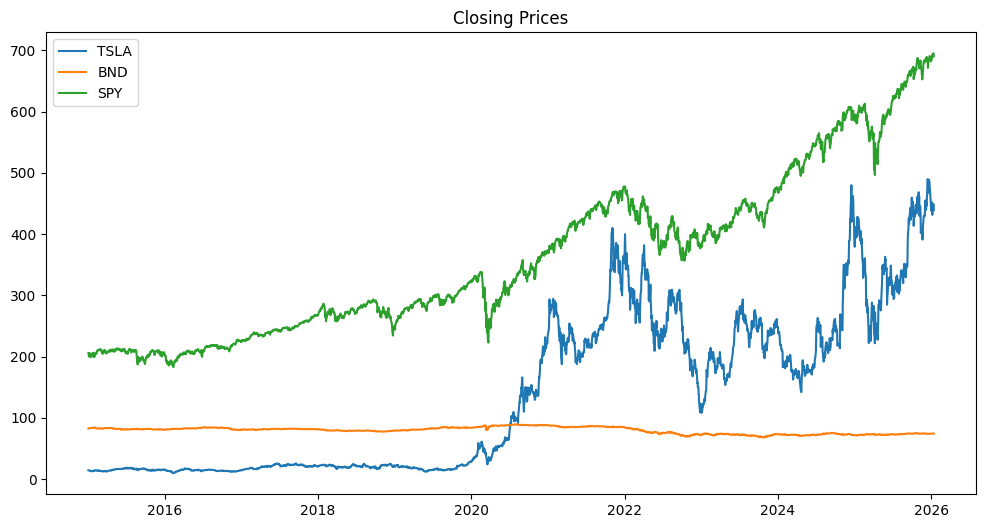

In [3]:
plt.figure(figsize=(12,6))
plt.plot(tsla["Close"], label="TSLA")
plt.plot(bnd["Close"], label="BND")
plt.plot(spy["Close"], label="SPY")
plt.legend()
plt.title("Closing Prices")
plt.show()


Text(0.5, 1.0, 'TSLA Return Distribution')

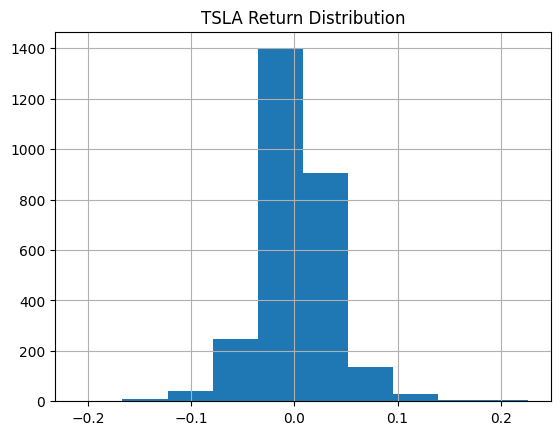

In [4]:
tsla["Return"] = tsla["Close"].pct_change()
bnd["Return"]  = bnd["Close"].pct_change()
spy["Return"]  = spy["Close"].pct_change()

tsla["Return"].hist()
plt.title("TSLA Return Distribution")


<Axes: title={'center': '30-Day Rolling Volatility'}, xlabel='Date'>

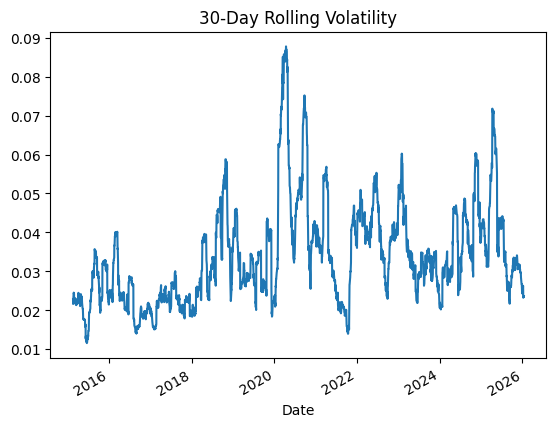

In [5]:
tsla["Volatility"] = tsla["Return"].rolling(30).std()
tsla["Volatility"].plot(title="30-Day Rolling Volatility")


In [6]:
result = adfuller(tsla["Close"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -0.7801569882105649
p-value: 0.8248814297221108


In [7]:
import numpy as np

mean_return = tsla["Return"].mean() * 252
volatility = tsla["Return"].std() * np.sqrt(252)
sharpe = mean_return / volatility

print("Annual Return:", mean_return)
print("Volatility:", volatility)
print("Sharpe Ratio:", sharpe)


Annual Return: 0.474914476119832
Volatility: 0.5769231419173879
Sharpe Ratio: 0.8231849992036496


In [8]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def adf_test(series, name):
    result = adfuller(series.dropna())
    return {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Stationary?": "Yes" if result[1] < 0.05 else "No"
    }

results = []

results.append(adf_test(tsla["Close"], "TSLA Close"))
results.append(adf_test(tsla["Return"], "TSLA Return"))

results.append(adf_test(bnd["Close"], "BND Close"))
results.append(adf_test(bnd["Return"], "BND Return"))

results.append(adf_test(spy["Close"], "SPY Close"))
results.append(adf_test(spy["Return"], "SPY Return"))

adf_table = pd.DataFrame(results)
adf_table


,Series,ADF Statistic,p-value,Stationary?
0,TSLA Close,-0.780157,8.248814e-01,No
1,TSLA Return,-53.019619,0.000000e+00,Yes
2,BND Close,-1.053047,7.334288e-01,No
3,BND Return,-15.017926,1.032454e-27,Yes
4,SPY Close,0.859856,9.925434e-01,No
5,SPY Return,-17.150965,6.942824e-30,Yes


In [9]:
import numpy as np

def risk_metrics(df, name):

    returns = df["Return"].dropna()

    sharpe = np.sqrt(252) * returns.mean() / returns.std()

    var_95 = np.percentile(returns, 5)

    return {
        "Asset": name,
        "Sharpe Ratio": sharpe,
        "VaR (95%)": var_95
    }

risk_results = []

risk_results.append(risk_metrics(tsla, "TSLA"))
risk_results.append(risk_metrics(bnd, "BND"))
risk_results.append(risk_metrics(spy, "SPY"))

risk_table = pd.DataFrame(risk_results)
risk_table


,Asset,Sharpe Ratio,VaR (95%)
0,TSLA,0.823185,-0.052529
1,BND,-0.148813,-0.005094
2,SPY,0.706943,-0.016763


In [11]:
import yfinance as yf
import pandas as pd

tickers = ["TSLA", "SPY", "BND"]

# Add auto_adjust=True and select 'Close'
data = yf.download(tickers, start="2015-01-01", end="2026-01-15", auto_adjust=True)["Close"]

returns = data.pct_change().dropna()

summary_table = pd.DataFrame({
    "Mean Price": data.mean(),
    "Std Dev Price": data.std(),
    "Min Price": data.min(),
    "Max Price": data.max(),
    "Mean Daily Return": returns.mean(),
    "Std Daily Return": returns.std()
})

# Make sure the folder 'task1_eda_outputs' exists or the save will fail
import os
if not os.path.exists("task1_eda_outputs"):
    os.makedirs("task1_eda_outputs")

summary_table.to_csv("task1_eda_outputs/table1_summary_statistics.csv")
print(summary_table)

[*********************100%***********************]  3 of 3 completed

        Mean Price  Std Dev Price   Min Price   Max Price  Mean Daily Return  \
Ticker                                                                         
BND      67.103517       4.669831   59.501591   75.817039           0.000081   
SPY     339.074724     141.925744  154.980881  695.159973           0.000567   
TSLA    138.472937     131.682073    9.578000  489.880005           0.001885   

        Std Daily Return  
Ticker                    
BND             0.003374  
SPY             0.011193  
TSLA            0.036343  
